In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
df=pd.read_csv("/content/Dataset for Data Analytics - Sheet1.csv")

In [ ]:
df.head(5)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
df.shape

(1200, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [5]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [6]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [7]:
print("Duplicate rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After removing duplicates:", df.shape)

Duplicate rows: 0
After removing duplicates: (1200, 14)


In [8]:
df.columns = df.columns.str.strip()


In [9]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()


In [10]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [11]:
df["CouponCode"] = df["CouponCode"].replace("nan", "No Coupon")

In [15]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)

In [12]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

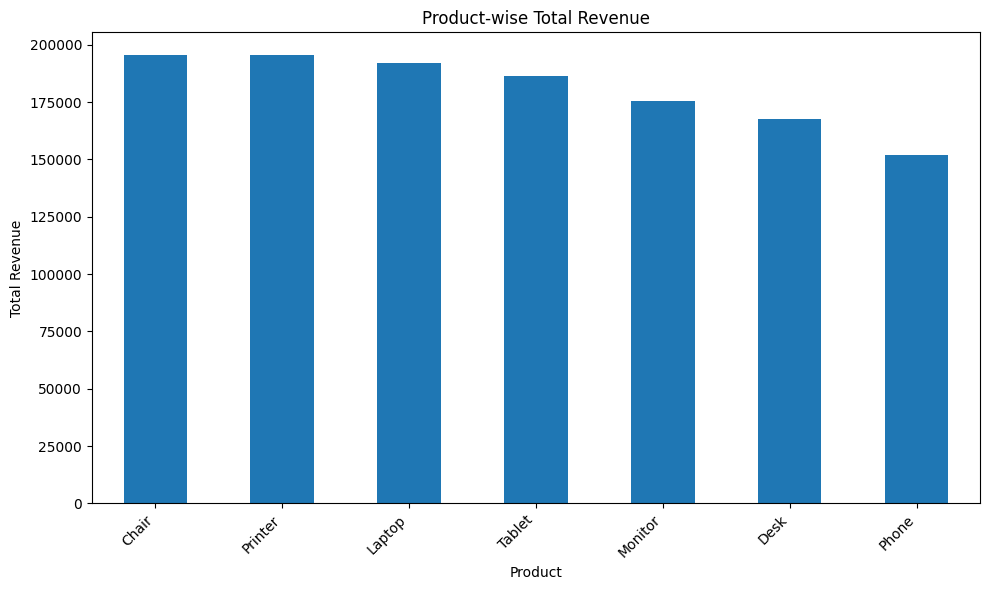

In [13]:
product_revenue = (
    df.groupby("Product")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
product_revenue.plot(kind="bar")
plt.title("Product-wise Total Revenue")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

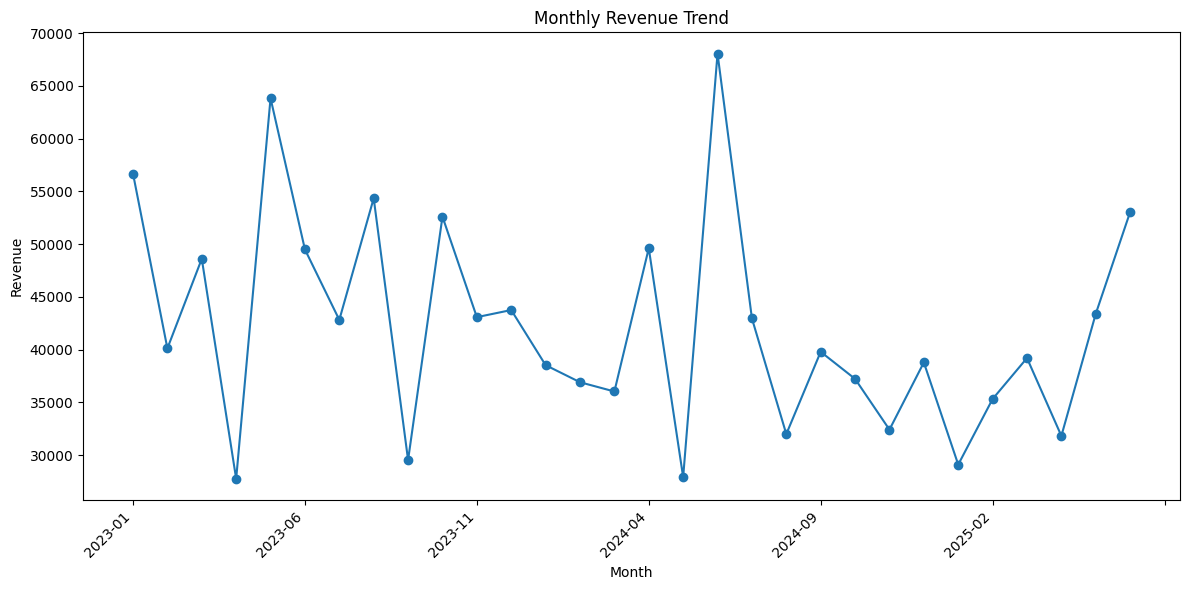

In [16]:
monthly_revenue = (
    df.groupby("Month")["TotalPrice"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

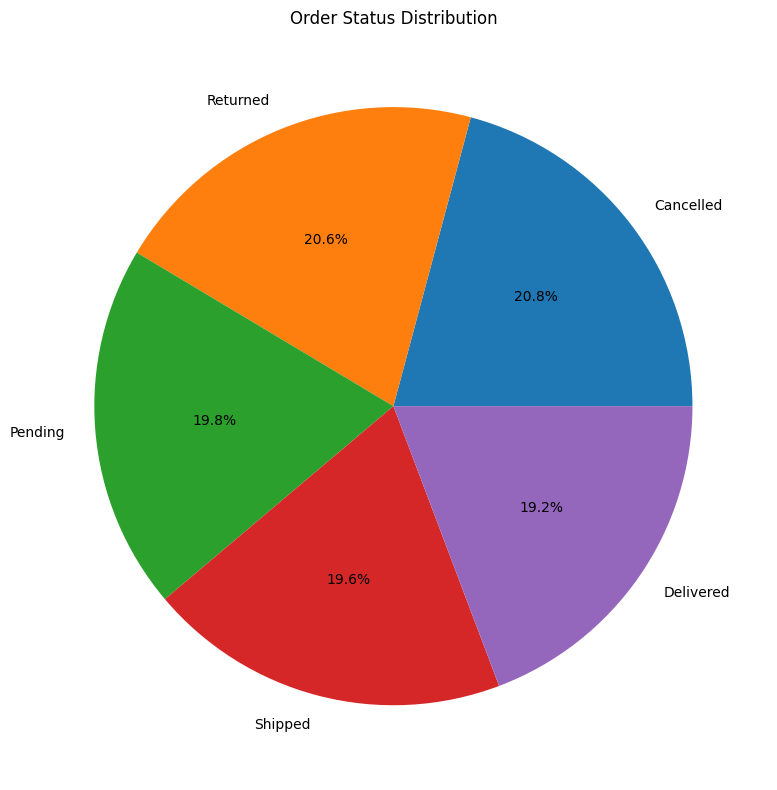

In [17]:
order_status = df["OrderStatus"].value_counts()

plt.figure(figsize=(8, 8))
order_status.plot(kind="pie", autopct="%1.1f%%")
plt.title("Order Status Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

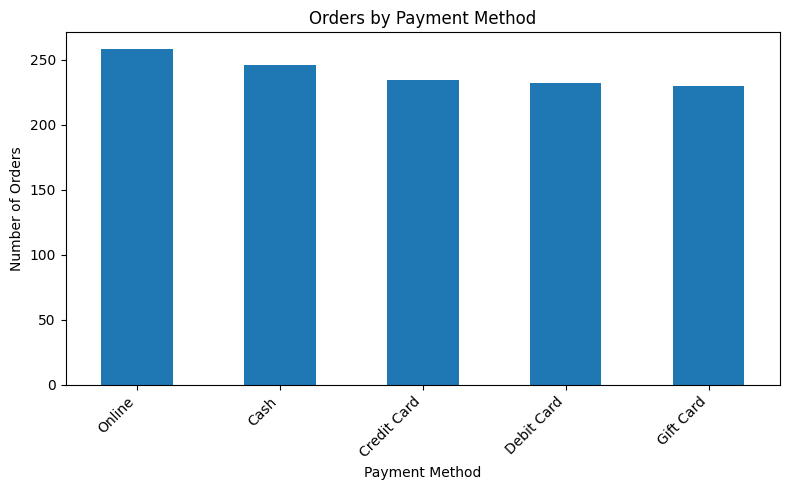

In [18]:
payment_count = df["PaymentMethod"].value_counts()

plt.figure(figsize=(8, 5))
payment_count.plot(kind="bar")
plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

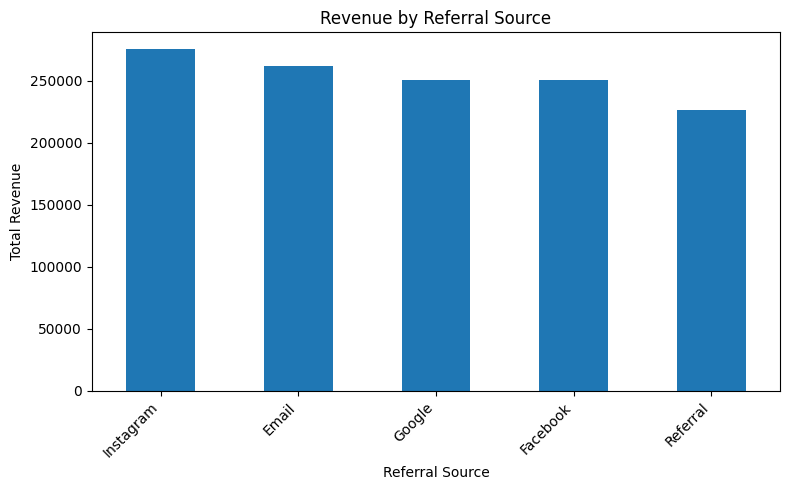

In [19]:
referral_revenue = (
    df.groupby("ReferralSource")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
referral_revenue.plot(kind="bar")
plt.title("Revenue by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

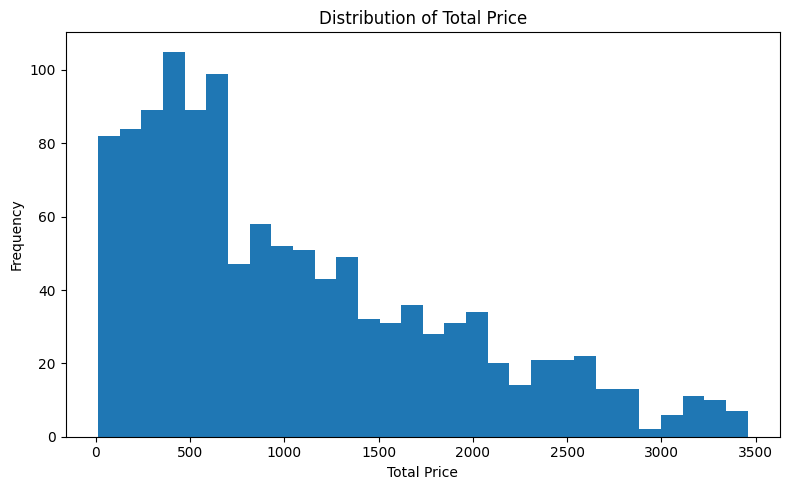

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df["TotalPrice"], bins=30)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

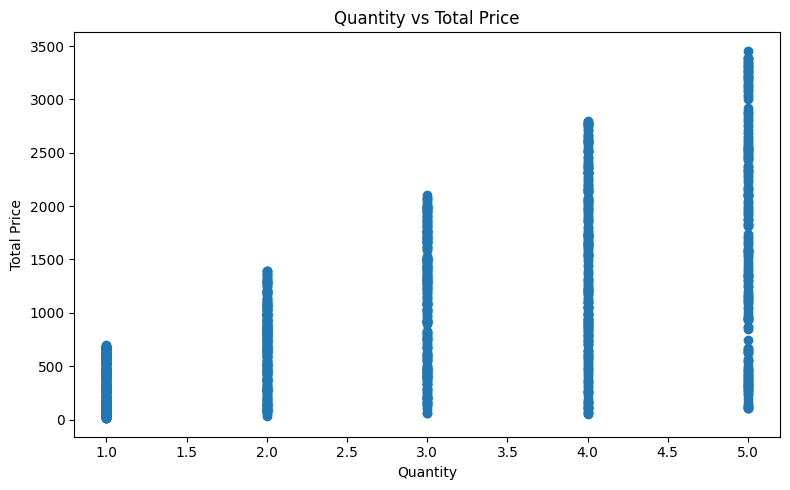

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Quantity"], df["TotalPrice"])
plt.title("Quantity vs Total Price")
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.tight_layout()
plt.show()

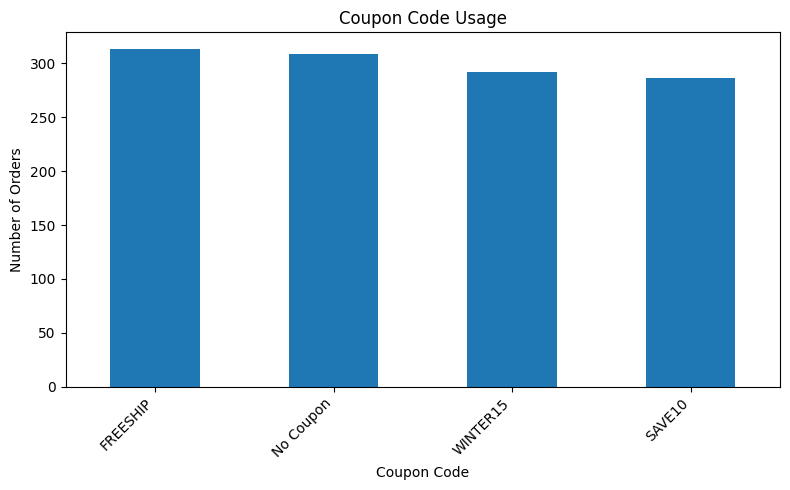

In [22]:
coupon_usage = df["CouponCode"].value_counts()

plt.figure(figsize=(8, 5))
coupon_usage.plot(kind="bar")
plt.title("Coupon Code Usage")
plt.xlabel("Coupon Code")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

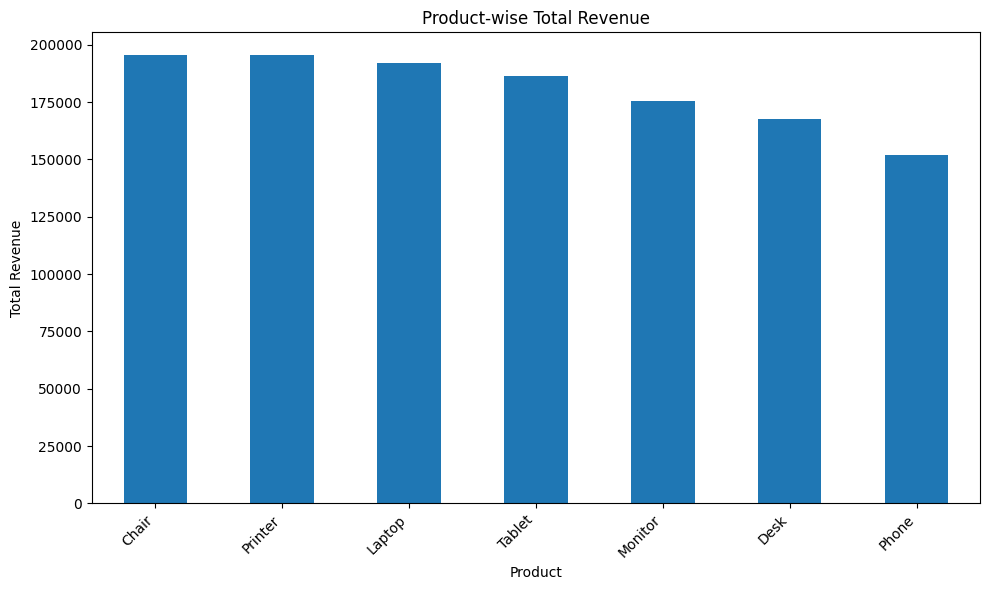

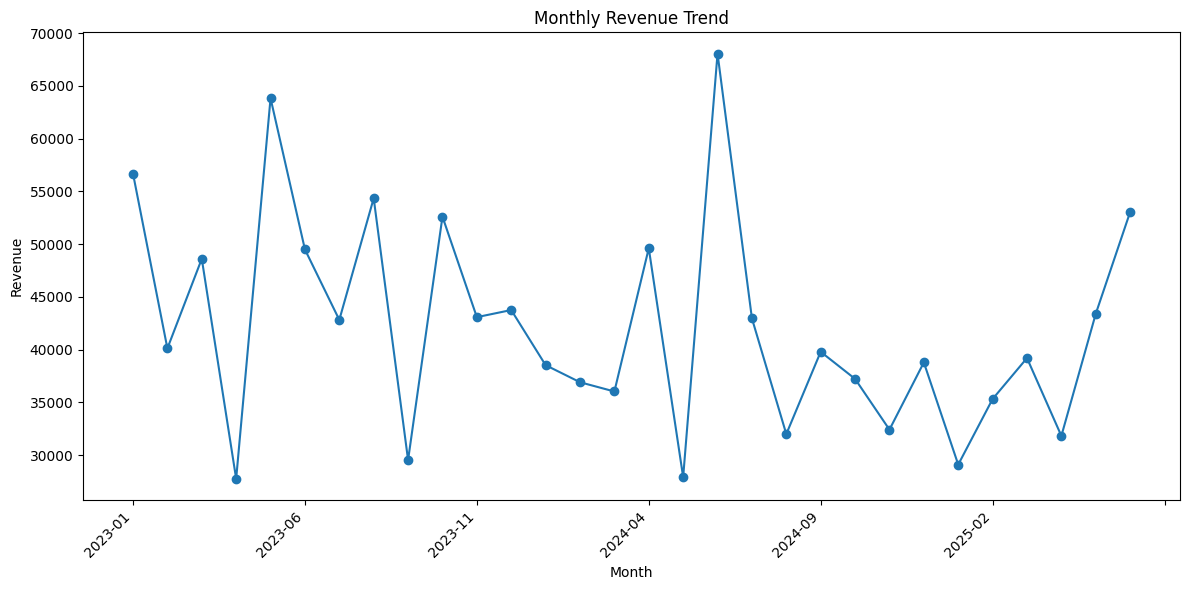

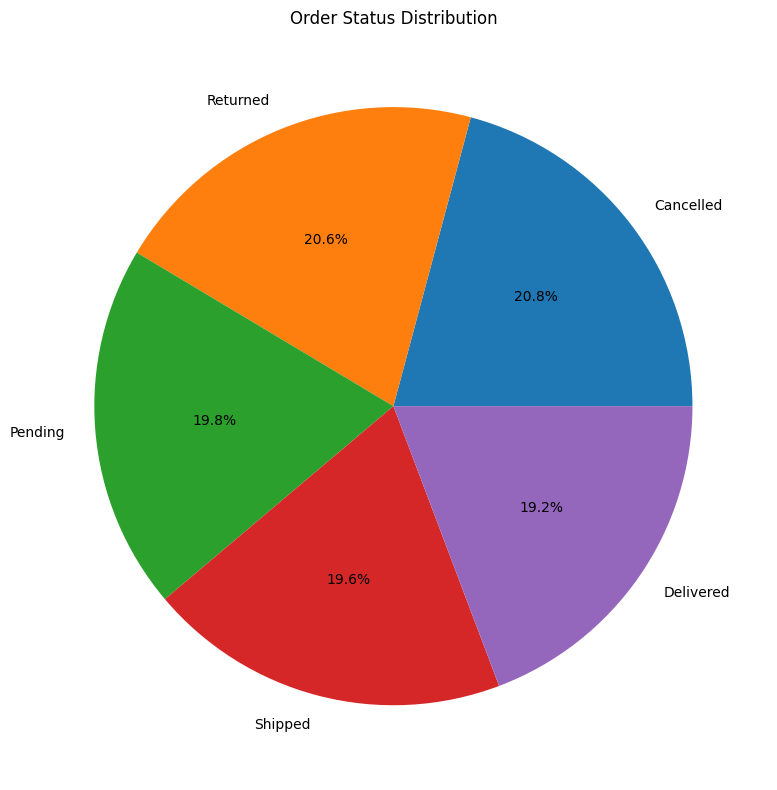

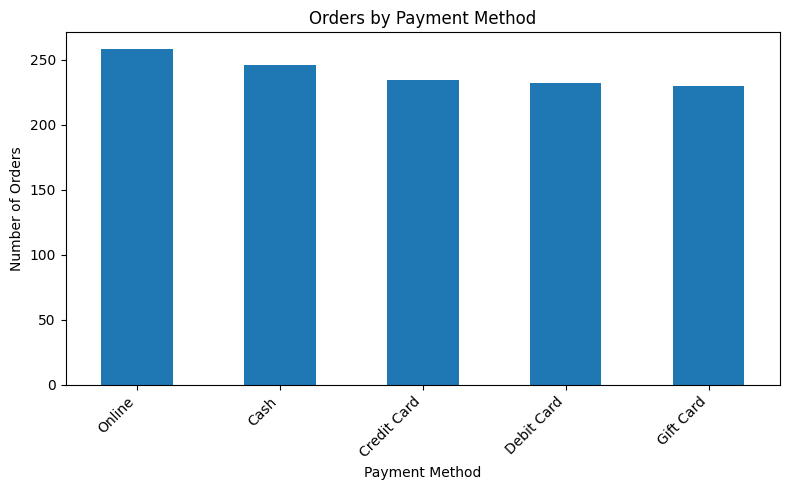

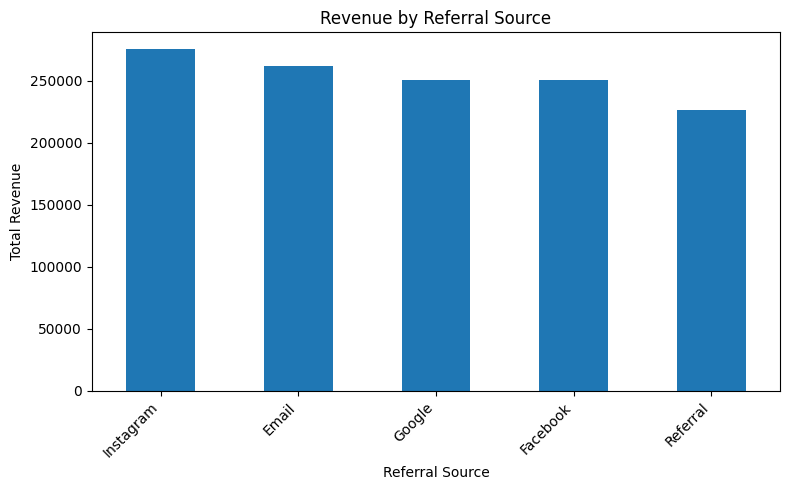

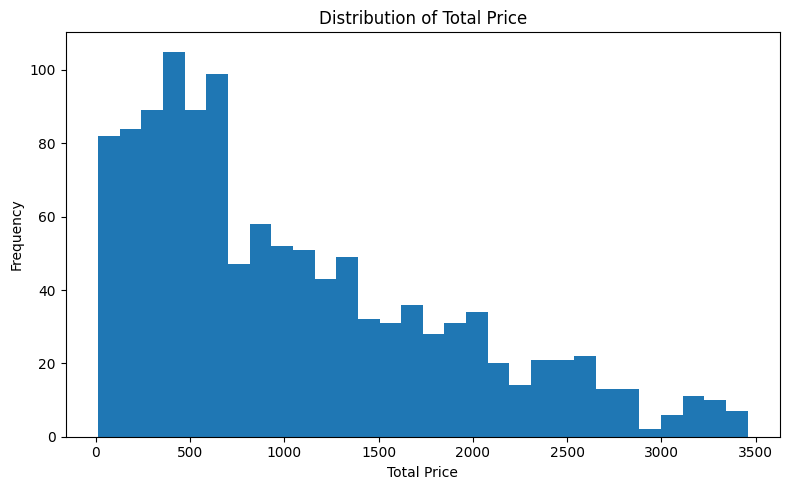

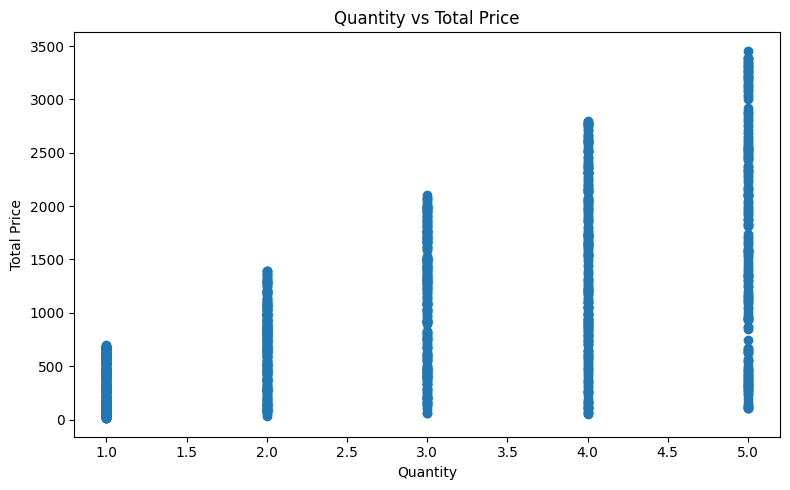

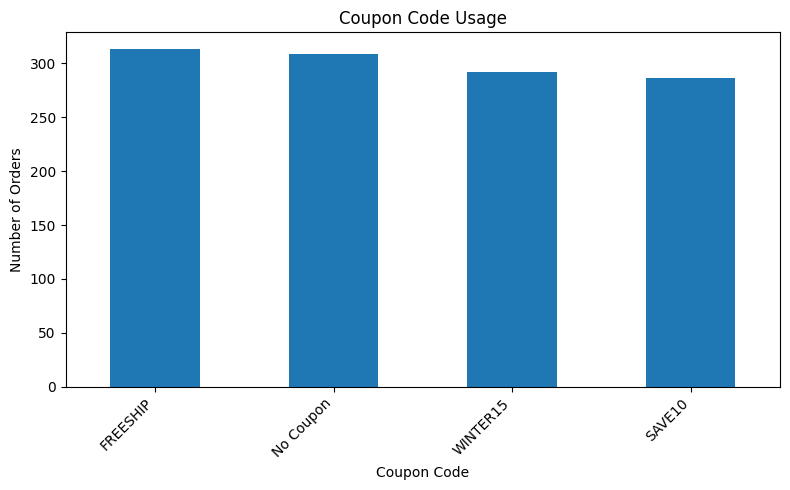

All charts saved successfully in output_screenshots folder.


In [23]:
# Create output folder
output_dir = Path("output_screenshots")
output_dir.mkdir(exist_ok=True)

# Product-wise Revenue
plt.figure(figsize=(10, 6))
product_revenue.plot(kind="bar")
plt.title("Product-wise Total Revenue")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "01_product_wise_revenue.png", dpi=300)
plt.show()

# Monthly Revenue Trend
plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "02_monthly_revenue_trend.png", dpi=300)
plt.show()

# Order Status Distribution
plt.figure(figsize=(8, 8))
order_status.plot(kind="pie", autopct="%1.1f%%")
plt.title("Order Status Distribution")
plt.ylabel("")
plt.tight_layout()
plt.savefig(output_dir / "03_order_status_distribution.png", dpi=300)
plt.show()

# Payment Method Orders
plt.figure(figsize=(8, 5))
payment_count.plot(kind="bar")
plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "04_payment_method_orders.png", dpi=300)
plt.show()

# Referral Source Revenue
plt.figure(figsize=(8, 5))
referral_revenue.plot(kind="bar")
plt.title("Revenue by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "05_referral_source_revenue.png", dpi=300)
plt.show()

# Total Price Distribution
plt.figure(figsize=(8, 5))
plt.hist(df["TotalPrice"], bins=30)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(output_dir / "06_total_price_distribution.png", dpi=300)
plt.show()

# Quantity vs Total Price
plt.figure(figsize=(8, 5))
plt.scatter(df["Quantity"], df["TotalPrice"])
plt.title("Quantity vs Total Price")
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.tight_layout()
plt.savefig(output_dir / "07_quantity_vs_total_price.png", dpi=300)
plt.show()

# Coupon Code Usage
plt.figure(figsize=(8, 5))
coupon_usage.plot(kind="bar")
plt.title("Coupon Code Usage")
plt.xlabel("Coupon Code")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "08_coupon_code_usage.png", dpi=300)
plt.show()

print("All charts saved successfully in output_screenshots folder.")